### Customer_Churn

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [33]:
df = pd.read_csv("./customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
# Extract the 5th column and store it in ‘customer_5’
customer_5 = df.iloc[:, 4]
display(customer_5)

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041     No
7042     No
Name: Dependents, Length: 7043, dtype: str

In [35]:
# Extract the 15th column and store it in ‘customer_15’
customer_15 = df.iloc[:, 14]
display(customer_15)

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040     No
7041     No
7042    Yes
Name: StreamingMovies, Length: 7043, dtype: str

In [36]:
# Extract all the male senior citizens whose payment method is electronic check and store the result in ‘senior_male_electronic’
senior_male_electronic = df[
    (df["gender"] == "Male")
    & (df["SeniorCitizen"] == 1)
    & (df["PaymentMethod"] == "Electronic check")
]
display(senior_male_electronic)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
55,1658-BYGOY,Male,1,No,No,18,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.45,1752.55,Yes
57,5067-XJQFU,Male,1,Yes,Yes,66,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,108.45,7076.35,No
78,0191-ZHSKZ,Male,1,No,No,30,Yes,No,DSL,Yes,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,74.75,2111.3,No
91,2424-WVHPL,Male,1,No,No,1,Yes,No,Fiber optic,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,74.70,74.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6837,6229-LSCKB,Male,1,No,No,6,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,79.70,497.6,No
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,105.90,334.65,Yes
6914,7142-HVGBG,Male,1,Yes,No,43,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.00,4414.3,Yes
6967,8739-WWKDU,Male,1,No,No,25,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,89.50,2196.15,Yes


In [37]:
# Extract all those customers whose tenure is greater than 70 months or their monthly charges is more than $100 and store the result in ‘customer_total_tenure’
customer_total_tenure = df[(df["tenure"] > 70) | (df["MonthlyCharges"] > 100)]
display(customer_total_tenure)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
12,8091-TTVAX,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,No,Credit card (automatic),100.35,5681.1,No
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
14,5129-JLPIS,Male,0,No,No,25,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,105.50,2686.05,No
15,3655-SNQYZ,Female,0,Yes,Yes,69,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),113.25,7895.15,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,6479.4,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No


In [38]:
#  Extract all the customers whose contract is of two years, payment method is mailed check and the value of churn is ‘Yes’ and store the result in ‘two_mail_yes
two_mail_yes = df[
    (df["Contract"] == "Two year")
    & (df["PaymentMethod"] == "Mailed check")
    & (df["Churn"] == "Yes")
]
display(two_mail_yes)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
268,6323-AYBRX,Male,0,No,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1099.6,Yes
5947,7951-QKZPL,Female,0,Yes,Yes,33,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,24.50,740.3,Yes
6680,9412-ARGBX,Female,0,No,Yes,48,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,No,Two year,Yes,Mailed check,95.50,4627.85,Yes


In [39]:
# Extract 333 random records from the customer_churndataframe and store the result in ‘customer_333’
customer_333 = df.sample(n=333, random_state=42)
display(customer_333)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,6890-PFRQX,Male,0,No,No,18,Yes,Yes,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,69.50,1199.4,No
3601,1552-CZCLL,Female,0,Yes,Yes,55,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),20.00,1087.25,No
2149,2014-MKGMH,Female,0,No,No,46,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,101.10,4674.4,No
5141,0303-WMMRN,Male,0,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.25,86.05,No


In [40]:
# Get the count of different levels from the ‘Churn’ column
churn_counts = df["Churn"].value_counts()
display(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

2. Data Visualization:\
● Build a bar-plot for the ’InternetService’ column:\
a. Set x-axis label to ‘Categories of Internet Service’\
b. Set y-axis label to ‘Count of Categories’\
c. Set the title of plot to be ‘Distribution of Internet Service’\
d. Set the color of the bars to be ‘orange’

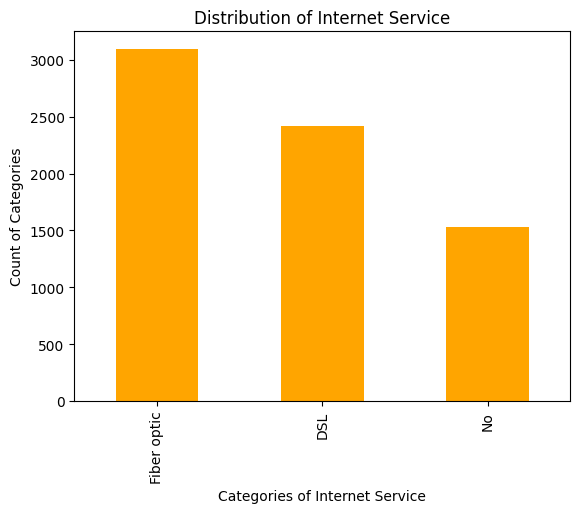

In [42]:
df["InternetService"].value_counts().plot(kind="bar", color="orange")
plt.xlabel("Categories of Internet Service")
plt.ylabel("Count of Categories")
plt.title("Distribution of Internet Service")
plt.show()

Build a histogram for the ‘tenure’ column:\
a. Set the number of bins to be 30\
b. Set the color of the bins to be ‘green’\
c. Assign the title ‘Distribution of tenure’

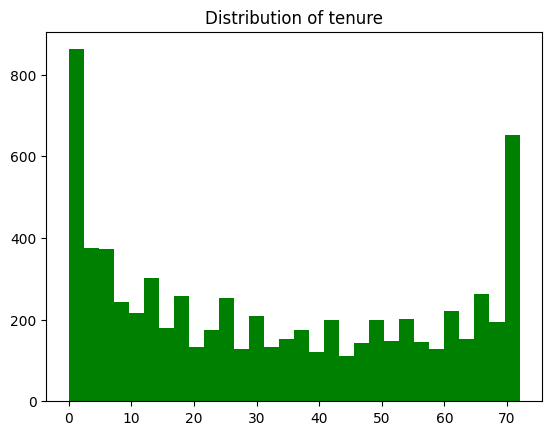

In [43]:
plt.hist(df["tenure"], bins=30, color="green")
plt.title("Distribution of tenure")
plt.show()

● Build a scatter-plot between ‘MonthlyCharges’ and ‘tenure’. Map
‘MonthlyCharges’ to the y-axis and ‘tenure’ to the ‘x-axis’:\
a. Assign the points a color of ‘brown’\
b. Set the x-axis label to ‘Tenure of customer’\
c. Set the y-axis label to ‘Monthly Charges of customer’\
d. Set the title to ‘Tenure vs Monthly Charges’\
e. Build a box-plot between ‘tenure’ & ‘Contract’. Map ‘tenure’ on the y-axis &\
f. ‘Contract’ on the x-axis.

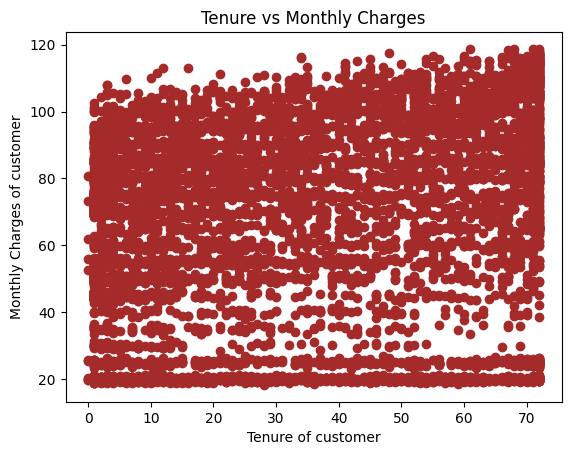

In [44]:
plt.scatter(df["tenure"], df["MonthlyCharges"], color="brown")
plt.xlabel("Tenure of customer")
plt.ylabel("Monthly Charges of customer")
plt.title("Tenure vs Monthly Charges")
plt.show()

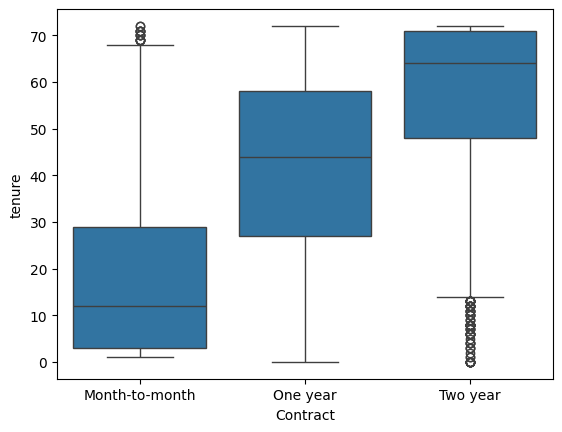

In [45]:
sns.boxplot(x="Contract", y="tenure", data=df)
plt.show()

3. Linear Regression:\
● Build a simple linear model where dependent variable is ‘MonthlyCharges’\
and independent variable is ‘tenure’:\
a. Divide the dataset into train and test sets in 70:30 ratio.\
b. Build the model on train set and predict the values on test set\
c. After predicting the values, find the root mean square error\
d. Find out the error in prediction & store the result in ‘error’\
e. Find the root mean square error

In [46]:
# prepare data
X = df[["tenure"]]
y = df["MonthlyCharges"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
display("RMSE:", rmse)

# Error
error = y_test - y_pred
display("Error:", error)

'RMSE:'

np.float64(29.165314179772544)

'Error:'

5373    28.809063
6297    39.050797
26      30.252151
1380    25.068683
6020    -3.870343
          ...    
3508    37.515025
2047    21.764479
2548    12.784669
6051   -39.613027
5762    41.803505
Name: MonthlyCharges, Length: 2113, dtype: float64

4. Logistic Regression:\
● Build a simple logistic regression model where dependent variable is\
‘Churn’ and independent variable is ‘MonthlyCharges’:\
a. Divide the dataset in 65:35 ratio\
b. Build the model on train set and predict the values on test set\
c. Build the confusion matrix and get the accuracy score\
d. Build a multiple logistic regression model where dependent variable is ‘Churn’ and independent variables are ‘tenure’ and ‘MonthlyCharges’\
e. Divide the dataset in 80:20 ratio\
f. Build the model on train set and predict the values on test set\
g. Build the confusion matrix and get the accuracy score

In [47]:
# Convert Churn to numeric
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Simple Logistic Regression (MonthlyCharges)
X = df[["MonthlyCharges"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.35)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

# Metrics
confusion_matrix(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.7222222222222222

In [ ]:
# Multiple Logistic Regression
X = df[["tenure", "MonthlyCharges"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)

confusion_matrix(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.7913413768630234

5. Decision Tree:\
● Build a decision tree model where dependent variable is ‘Churn’ and\
independent variable is ‘tenure’:\
a. Divide the dataset in 80:20 ratio\
b. Build the model on train set and predict the values on test set\
c. Build the confusion matrix and calculate the accuracy

In [ ]:
X = df[["tenure"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

confusion_matrix(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.7579843860894251

6. Random Forest:\
● Build a Random Forest model where dependent variable is ‘Churn’ and\
independent variables are ‘tenure’ and ‘MonthlyCharges’:\
a. Divide the dataset in 70:30 ratio\
b. Build the model on train set and predict the values on test set\
c. Build the confusion matrix and calculate the accuracy

In [ ]:
X = df[["tenure", "MonthlyCharges"]]
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

confusion_matrix(y_test, y_pred)
accuracy_score(y_test, y_pred)

0.7501183151916706